In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import linear_model
from sklearn.metrics import mean_squared_error

In [5]:
insurance_data = pd.read_csv("insurance.csv")
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [6]:
X=insurance_data.drop(columns = ["charges"])
Y=insurance_data["charges"]
X["sex"] = X["sex"].map({"female":1,"male":0})
X["smoker"] = X["smoker"].map({"yes":1,"no":0})

X = pd.get_dummies(X,columns=["region"],dtype = int, drop_first = True)

X["ageSmoker"] = X["age"]*X["smoker"]
X["bmiSmoker"] = X["bmi"]*X["smoker"]

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,test_size = 0.2,random_state = 42
)

from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha = 0.5) 
lasso_model.fit(X_train,Y_train)

,alpha,0.5
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Mse for alpha = 0.001 20922599.871035963
Mse for alpha = 0.1 20921803.698431373
Mse for alpha = 1 20914832.635089137
Mse for alpha = 2 20908106.779954523
Mse for alpha = 5 20890881.000633497
Mse for alpha = 10 20872844.794796683
Mse for alpha = 20 20877828.53237883
Mse for alpha = 30 20937537.133939773
Mse for alpha = 40 21046489.29389078
Mse for alpha = 50 21196929.86960891
Mse for alpha = 100 22423172.68602325
Mse for alpha = 11 20870880.242269978


<Axes: >

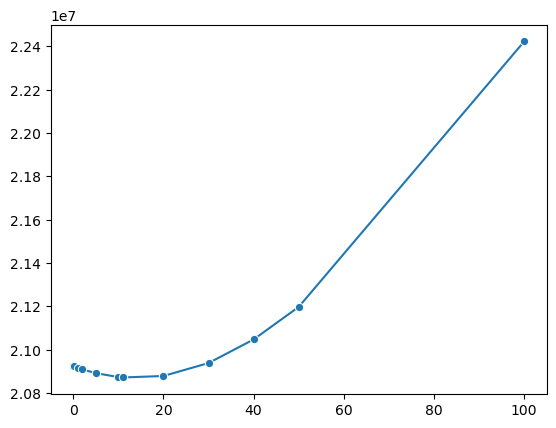

In [10]:
Y_pred = lasso_model.predict(X_test)
MSE= mean_squared_error(Y_test, Y_pred)
#  we need to find at what value of alpha the MSE reach it lowedt for thei lasso
alphas=[0.001,0.1,1,2,5,10,20,30,40,50,100]
mses=[]
for i in alphas:
    lasso_model = Lasso(alpha = i) 
    lasso_model.fit(X_train,Y_train)
    Y_pred = lasso_model.predict(X_test)
    MSE= mean_squared_error(Y_test, Y_pred)
    print(f"Mse for alpha = {i}",MSE)
    mses.append(MSE)
sns.lineplot(x=alphas,y=mses,marker='o')
# this is not the perfect way for finding best alpha

In [34]:
#we use technique called cross validation for finding best alpha for our model
# for that we have model called LassoCV or RedgeCV

from sklearn.linear_model import LassoCV
a=[0.001,0.1,1,2,5,10,20,30,40,50,100]
lasso_cv_model = LassoCV(
    alphas = a,
    cv=5,
    fit_intercept = True,
    max_iter = 1000,
    random_state = 42
)
lasso_cv_model.fit(X_train,Y_train)
print("best alpha",lasso_cv_model.alpha_)

# mean squared error
from sklearn.metrics import mean_squared_error
y_pred = lasso_cv_model.predict(X_test)
mse=mean_squared_error(Y_test,y_pred)
print("mse",mse)

from sklearn.metrics import r2_score
r2=r2_score(Y_test,Y_pred)
print("r2",r2)

best alpha 0.001
mse 20922599.871035963
r2 0.8655648903425925


In [41]:
# ridge regression
from sklearn.linear_model import RidgeCV
a=[0.001,0.1,1,2,5,10,20,30,40,50,100]
ridge_rg = RidgeCV(
    alphas = a,
    cv=5,
    fit_intercept=True,
)
ridge_rg.fit(X_train,Y_train)
print("best alpha",ridge_rg.alpha_)
y_pred = ridge_rg.predict(X_test)
mse=mean_squared_error(Y_test,Y_pred)
r2=r2_score(Y_test,y_pred)
print("Mse = ",mse)
print("r2 = ",r2)

best alpha 0.001
Mse =  20870880.242269978
r2 =  0.8652329243520364


In [ ]:
# elastic net 